In [155]:
import os
import pandas as pd
import numpy as np

%load_ext autoreload
%autoreload 2

%matplotlib inline

%config InlineBackend.figure_format = 'svg' # other available formats are: 'retina', 'png', 'jpeg', 'pdf'

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Example - MNIST Data

https://umap-learn.readthedocs.io/en/latest/basic_usage.html

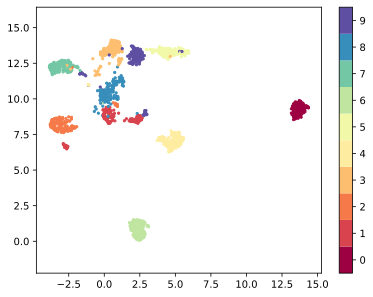

In [376]:
import pandas as pd
from sklearn.datasets import load_digits

# get digits data
digits = load_digits()

# make dataframe
digits_df = pd.DataFrame(digits.data[:,1:11])
digits_df['digit'] = pd.Series(digits.target).map(lambda x: 'Digit {}'.format(x))

# calculate embedding with 2 n_components
embedding_2_comp = calculate_embedding(data=digits.data, n_components=2)

# visualize embedding (static display)
plot_umap(embedding_2_comp, target=digits.target) 

# calculate embedding with 3 n_components
embedding_3_comp = calculate_embedding(data=digits.data, n_components=3)

# visualize 3d embedding (interactive display)
df_embedding = pd.DataFrame(embedding_3_comp, columns=['x', 'y', 'z'])
df_target = pd.DataFrame(digits.target, columns=['color'])
dataframe = pd.concat([df_embedding, df_target], axis=1)

plot_umap_3d(dataframe, hue='color')

## HBN

In [585]:
from hbn.data import make_dataset
from hbn.constants import Defaults

# make train/test splits for participants
make_dataset.make_train_test_splits(column='DX_01', out_dir=Defaults.MODEL_SPEC_DIR);


## Visualize embeddings for HBN data

In [ ]:
phenotype_widget = get_phenotype_inputs()
display(phenotype_widget)

participant_widget = get_participant_inputs()
display(participant_widget)

In [556]:
# get data
features, target = get_data(phenotype_widget, participant_widget)

reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Child_Measures/Motor_Skills/Grooved_Pegboard.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Child_Measures/Vision/Ishihara_Color_Vision_Test.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Child_Measures/Questionnaire_Measures_of_Emotional_and_Cognitive_Status/Mood_and_Feelings_Questionnaire_–_Long_Version.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Child_Measures/Questionnaire_Measures_of_Emotional_and_Cognitive_Status/Conners_ADHD_Rating_Scales_-_Self_Report__Short_Form.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Child_Measures/Neurologic_Function/Electro-encephalography.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Clinical_Measures/Clinical_Diagnosis_Demograph

In [559]:
# visualize UMAP embedding

embedding_3_comp = calculate_embedding(
                        data=features, 
                        n_components=3,
                        n_neighbors=5, 
                        min_dist=.1, 
                        metric='euclidean'
                        )
visualize_embedding(embedding=embedding_3_comp, target=target)

In [578]:
u, s, vt, pcs = compute_svd(features)

print(variance_explained(features, pcs=[1]))


0.8746249308470714


In [582]:
k_means_n_dims_heatmap(dataframe=features, num_clusters=2)

<Figure size 2000x800 with 0 Axes>